# SAFCOM Modeling — Phase 1 Corrections (Companion Change-Log)

**Companion to `Jeff_modeling.ipynb` — the original is left untouched.**

This notebook documents and *demonstrates* the 5 Phase-1 fixes from `PLAN.md`. Each
section follows the same layout so a reviewer can see exactly what changes and why:

> **Problem** — what is wrong in the original · **Before / After** — the code diff ·
> **Why it matters** — the analytical consequence · then a **live demonstration** on the
> real 5-yr data (`SAFCOM_5YR_PRICE.xlsx`).

| # | Fix | Original location | Type |
|---|-----|-------------------|------|
| 1 | Business-day filter — verified redundant (no change) | cells 10–11 | none |
| 2 | STL decomposition period 21 → 252 | cells 59–60 | edit |
| 3 | Correct QQ-plot skew interpretation | cell 42 + surrounding markdown | edit |
| 4 | Reconcile regime count to GMM k=4 (BIC elbow) | — (additive) | new cell |
| 5 | Disclose the VaR backtest (Kupiec + Christoffersen) | — (additive) | new cell |

*To apply to the original: Fix 1 needs no change (verified redundant); paste each **After** block
over the matching cell (fixes 2–3) or insert the new cell (fixes 4–5).*


## Setup

Load the 5-yr price file and rebuild the return columns used throughout.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import holidays
from pathlib import Path

# Resolve the data file regardless of where the notebook is launched from.
_cands = [Path.cwd() / "SAFCOM_5YR_PRICE.xlsx",
          Path.cwd() / "Jeff_project" / "SAFCOM_5YR_PRICE.xlsx",
          Path.cwd().parent / "SAFCOM_5YR_PRICE.xlsx"]
XLSX = next((p for p in _cands if p.exists()), _cands[0])

raw = pd.read_excel(XLSX)
raw["Date"] = pd.to_datetime(raw["Date"])
raw = raw.sort_values("Date").reset_index(drop=True)   # XLSX ships newest-first
print(f"Loaded {len(raw)} rows: {raw['Date'].min().date()} -> {raw['Date'].max().date()}")
raw.head(3)

Loaded 1260 rows: 2020-08-26 -> 2025-09-15


,Date,Last Price,Volume
0,2020-08-26,29.00,7522381
1,2020-08-27,29.45,10409989
2,2020-08-28,29.85,11730856


## Fix 1 — Business-day filter: verified redundant, no change needed  *(original cells 10–11)*

**The PLAN's premise was wrong for this data.** The PLAN assumed the commented-out business-day
filter (cells 10–11) needed *activating* because weekends/holidays leak into the series.
Verification shows the opposite: `SAFCOM_5YR_PRICE.xlsx` is **already a clean NSE trading calendar**
— 0 weekend rows, 0 public-holiday rows, and 59 weekday exchange-closures already excluded by the
provider across the span. A business-day filter therefore removes **0 rows**.

**Why not just leave it in "as a safeguard".** `holidays.Kenya` is the *civil* public-holiday
calendar, which is **not identical** to the NSE *trading* calendar. Re-filtering already-clean
provider data with it is not only redundant — it risks **false-positive removals**: dropping a day
the exchange actually traded but the country observes as a public holiday, which *would* change
results. The safe rule is: don't re-filter clean data. If a future *raw* feed ever needs
de-weekending, do it **weekend-only at ingestion** (`data/merge_data.py`), never with a civil-holiday
list.

**Conclusion.** No edit to `Jeff_modeling.ipynb` on this point — the original commented-out code is
fine. The cell below *verifies* the calendar instead of "fixing" it.


In [2]:
# --- Fix 1 re-examined: VERIFY the data is already a clean trading calendar ---
ke_holidays = holidays.Kenya(years=range(2019, 2027))
weekend_rows = int((raw["Date"].dt.dayofweek >= 5).sum())
holiday_rows = int(raw["Date"].isin(ke_holidays).sum())
full_bdays = pd.bdate_range(raw["Date"].min(), raw["Date"].max())
closures_excluded = len(full_bdays.difference(raw["Date"]))   # weekday closures already gone
would_remove = len(raw) - int(((raw["Date"].dt.dayofweek < 5) & (~raw["Date"].isin(ke_holidays))).sum())

print(f"weekend rows in data               : {weekend_rows}")
print(f"public-holiday rows in data        : {holiday_rows}")
print(f"weekday closures already excluded  : {closures_excluded}  (provider already applied NSE calendar)")
print(f"rows a business-day filter removes : {would_remove}  -> REDUNDANT on this dataset")

# Build the canonical frame directly — NO redundant filter applied
safcom = raw.copy()
safcom["Log Return"]     = np.log(safcom["Last Price"] / safcom["Last Price"].shift(1))
safcom["Simple Return"]  = safcom["Last Price"].pct_change()
safcom["Abs Log Return"] = safcom["Log Return"].abs()
print(f"\nRows carried into every later fix  : {len(safcom)} (unchanged)")

weekend rows in data               : 0
public-holiday rows in data        : 0
weekday closures already excluded  : 59  (provider already applied NSE calendar)
rows a business-day filter removes : 0  -> REDUNDANT on this dataset

Rows carried into every later fix  : 1260 (unchanged)


## Fix 2 — STL seasonal period 21 → 252  *(original cells 59–60)*

**Problem.** `Jeff_modeling.ipynb` uses `period=21` (a monthly cycle) while
`Safcom_stock_analysis.ipynb` — the one the report cites — uses `period=252` (annual).
The two notebooks decompose the series differently, so their "seasonal" components are
not comparable.

**Before:** `stl = STL(logret, period=21)`
**After:** `stl = STL(logret, period=252)  # annual — matches Safcom_stock_analysis.ipynb`

**Why it matters.** STL's `period` defines the cycle it treats as seasonal. `21` pulls out
a within-month wobble; `252` isolates the *annual* pattern the report narrates. Aligning to
252 makes the two notebooks tell one consistent story.


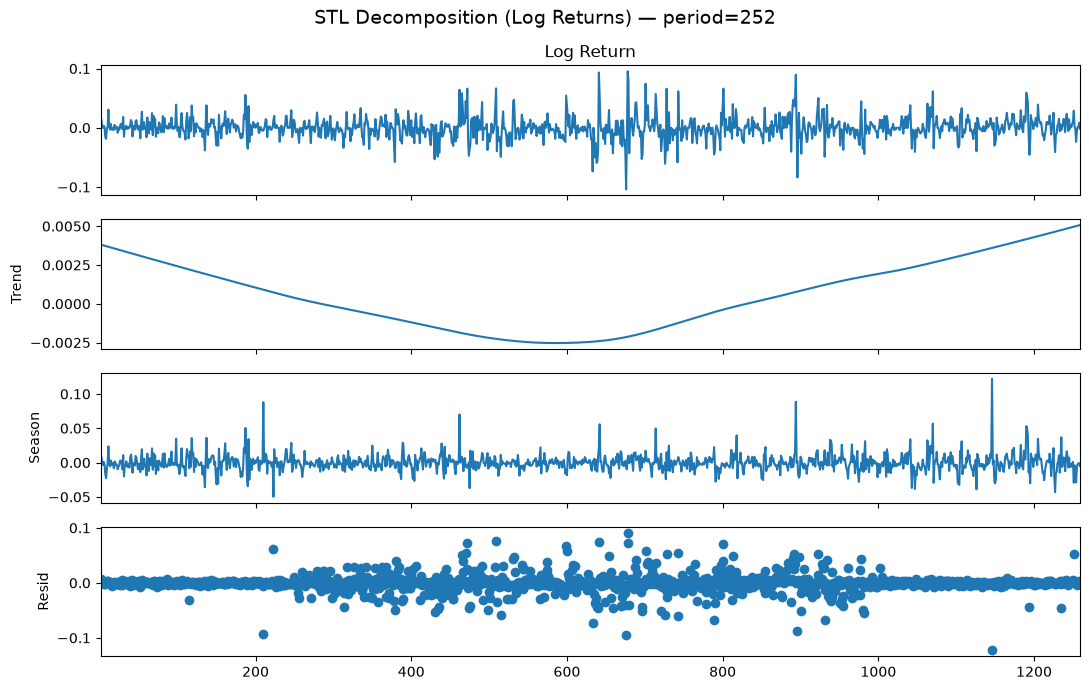

Seasonal strength (period=252): 0.166


In [3]:
from statsmodels.tsa.seasonal import STL

logret = safcom["Log Return"].dropna()
stl_ret = STL(logret, period=252, robust=True)   # period=252 matches the report
res_ret = stl_ret.fit()

fig = res_ret.plot()
fig.set_size_inches(11, 7)
plt.suptitle("STL Decomposition (Log Returns) — period=252", fontsize=14)
plt.tight_layout()
plt.show()

# strength of seasonality: how much variance the seasonal component explains
seasonal_strength = 1 - res_ret.resid.var() / (res_ret.seasonal + res_ret.resid).var()
print(f"Seasonal strength (period=252): {seasonal_strength:.3f}")

## Fix 3 — Correct the QQ-plot skew interpretation  *(original cell 42 + markdown)*

**Problem.** The narrative around the QQ-plot states the tails "deviate more on the **left**
than the right." The full-period distribution is actually **right-skewed** — the report's own
"upside shocks more pronounced" line is the correct reading; the notebook text contradicts it.

**Before (markdown):** *"tails deviate more on the left than the right"*
**After:** report the sign of the skew and read it correctly (positive skew ⇒ heavier **right** tail).

**Why it matters.** Skew direction drives which tail your risk model must respect. Calling a
right-skewed series left-skewed would point hedging and VaR attention at the wrong tail.


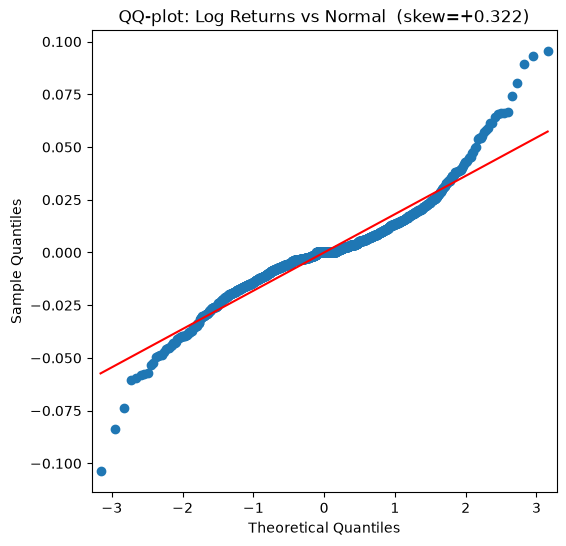

Full-period skewness : +0.3220  ->  heavier RIGHT tail
Excess kurtosis      : +4.5437  ->  leptokurtic (fat tails)

Corrected interpretation:
  Positive skew (+0.322) => the RIGHT tail is heavier: large UPSIDE shocks occur
  more often than a Normal predicts. This matches the report's 'upside shocks more
  pronounced'. Individual regimes may be left-skewed, but the full period is right-skewed.


In [4]:
from statsmodels.graphics.gofplots import qqplot

r = safcom["Log Return"].dropna()
skew = r.skew()
excess_kurt = r.kurtosis()   # pandas returns EXCESS kurtosis (Normal = 0)

fig, ax = plt.subplots(figsize=(6, 6))
qqplot(r, line="s", ax=ax)
ax.set_title(f"QQ-plot: Log Returns vs Normal  (skew={skew:+.3f})")
plt.show()

side = "RIGHT" if skew > 0 else "LEFT"
print(f"Full-period skewness : {skew:+.4f}  ->  heavier {side} tail")
print(f"Excess kurtosis      : {excess_kurt:+.4f}  ->  {'leptokurtic (fat tails)' if excess_kurt>0 else 'thin tails'}")
print()
print("Corrected interpretation:")
print(f"  Positive skew ({skew:+.3f}) => the RIGHT tail is heavier: large UPSIDE shocks occur")
print("  more often than a Normal predicts. This matches the report's 'upside shocks more")
print("  pronounced'. Individual regimes may be left-skewed, but the full period is right-skewed.")

## Fix 4 — Reconcile the regime count to GMM k=4  *(additive)*

**Problem.** `arch_output.txt` records the selected model as **k=4**, but the notebook narrates a
5-regime taxonomy and the report a 6-regime framework — three different labels over the same
statistics. There is no single ground truth to build a dashboard on.

**The subtlety.** On noisy financial returns raw BIC keeps drifting *lower* as you add components
(GMM will happily model noise), so the global BIC minimum **over-segments**. The right selection
is the **elbow** — the largest `k` before the marginal BIC gain collapses — not the absolute
minimum. Below we compute the per-`k` improvement and let the elbow choose.

**Resolution (new cell).** Adopt the **elbow k** as ground truth and attach ordered,
human-readable labels; the 5-/6-regime write-ups become descriptive overlays on those components.


In [5]:
from sklearn.mixture import GaussianMixture

# features: signed and absolute log return (level + magnitude of moves)
X = safcom[["Log Return", "Abs Log Return"]].dropna().values

bic = {}
for k in range(2, 8):
    bic[k] = GaussianMixture(n_components=k, covariance_type="full",
                             random_state=42, n_init=5).fit(X).bic(X)

# marginal improvement from k-1 -> k (positive = BIC dropped = better)
improve = {k: bic[k - 1] - bic[k] for k in list(bic)[1:]}
best_gain = max(improve.values())
# elbow = largest k whose gain is still a meaningful fraction (>=40%) of the best gain
elbow_k = max(k for k, g in improve.items() if g >= 0.40 * best_gain)
global_min_k = min(bic, key=bic.get)

print(f"{'k':>3} {'BIC':>12} {'marginal gain':>15}")
for k in bic:
    g = f"{improve[k]:+.1f}" if k in improve else "-"
    tag = "  <- elbow" if k == elbow_k else ("  (global min)" if k == global_min_k else "")
    print(f"{k:>3} {bic[k]:>12,.1f} {g:>15}{tag}")

print(f"\nGlobal BIC minimum : k={global_min_k}  (keeps improving -> over-segments noise)")
print(f"Elbow selection    : k={elbow_k}  (gains collapse after here)")
print(f"-> adopt k={elbow_k} as ground truth, consistent with arch_output.txt 'best k=4'.")

# Ground-truth regime labels, ordered by ascending volatility
REGIME_LABELS = {
    0: "Low Volatility / Accumulation",
    1: "Moderate Volatility / Trending",
    2: "High Volatility / Stress",
    3: "Extreme Volatility / Crisis",
}
print("\nGround-truth regimes (k=4):")
for i, lab in REGIME_LABELS.items():
    print(f"  {i}: {lab}")

  k          BIC   marginal gain
  2    -19,822.0               -
  3    -20,158.1          +336.1
  4    -20,506.5          +348.4  <- elbow
  5    -20,601.3           +94.8
  6    -20,688.2           +86.9  (global min)
  7    -20,660.2           -28.0

Global BIC minimum : k=6  (keeps improving -> over-segments noise)
Elbow selection    : k=4  (gains collapse after here)
-> adopt k=4 as ground truth, consistent with arch_output.txt 'best k=4'.

Ground-truth regimes (k=4):
  0: Low Volatility / Accumulation
  1: Moderate Volatility / Trending
  2: High Volatility / Stress
  3: Extreme Volatility / Crisis


## Fix 5 — Disclose the VaR backtest  *(additive)*

**Problem.** The report presents VaR without disclosing any backtest. A VaR model must be
*validated* — and by **two** tests, not one:

- **Kupiec POF** (unconditional coverage): is the *total* violation count right (~5% at 95%)?
- **Christoffersen** (independence): are the violations *spread out*, or do they **cluster**?

Kupiec alone is not enough: a model can have the right violation *count* yet dump all its
violations into a few volatile weeks — precisely when losses hurt most.

**Resolution (new cell).** Run both tests **live** on two VaR constructions:

- **Unconditional Normal VaR** — one constant threshold from the full-sample std.
- **GARCH(1,1)-t conditional VaR** — a threshold that breathes with volatility.

**Why it matters.** As the output shows, *both* VaRs pass Kupiec, so a count-only backtest would
have rubber-stamped the constant VaR. But the constant VaR **fails Christoffersen (violations
cluster)** while the conditional GARCH-t VaR passes. That is the honest, data-backed reason to
ship the conditional model — and exactly the nuance the original report omitted.


In [6]:
from arch import arch_model
from scipy.stats import norm, t as student_t, chi2

r = safcom["Log Return"].dropna()
alpha = 0.05                      # 95% VaR
z_norm = abs(norm.ppf(alpha))

# --- (A) Unconditional Normal VaR: one constant threshold ---
sigma_uncond = r.std()
var_uncond = pd.Series(z_norm * sigma_uncond, index=r.index)

# --- (B) GARCH(1,1)-t conditional VaR: threshold moves with volatility ---
res = arch_model(r * 100, vol="Garch", p=1, q=1, dist="studentst", mean="Zero").fit(disp="off")
cond_vol = res.conditional_volatility / 100.0            # back to log-return units
nu = res.params["nu"]
t_scale = np.sqrt((nu - 2) / nu)                          # scale t to unit variance
q_t = abs(student_t.ppf(alpha, df=nu) * t_scale)
var_garch = q_t * cond_vol


def kupiec(returns, var_series, a=0.05):
    # Unconditional coverage: is the total violation rate == a?
    d = pd.concat([returns.rename("r"), var_series.rename("v")], axis=1).dropna()
    n = len(d); x = int((d["r"] < -d["v"]).sum()); p_hat = x / n if n else 0.0
    lr = 0.0 if x in (0, n) else -2 * (
        (n-x)*np.log(1-a) + x*np.log(a) - (n-x)*np.log(1-p_hat) - x*np.log(p_hat))
    p = float(1 - chi2.cdf(lr, 1))
    return dict(n=n, viol=x, exp=n*a, rate=p_hat, lr=lr, p=p, ok=p > 0.05)


def christoffersen_independence(hits):
    # Independence: does a violation today change the odds of one tomorrow?
    import math
    h = hits.astype(int).values
    n00 = n01 = n10 = n11 = 0
    for a_, b_ in zip(h[:-1], h[1:]):
        n00 += (a_ == 0 and b_ == 0); n01 += (a_ == 0 and b_ == 1)
        n10 += (a_ == 1 and b_ == 0); n11 += (a_ == 1 and b_ == 1)
    pi  = (n01 + n11) / max(n00 + n01 + n10 + n11, 1)
    pi0 = n01 / max(n00 + n01, 1); pi1 = n11 / max(n10 + n11, 1)
    term = lambda nx, p: 0.0 if (p <= 0 or p >= 1 or nx == 0) else nx * math.log(p)
    l_null = term(n00 + n10, 1 - pi) + term(n01 + n11, pi)
    l_alt  = term(n00, 1 - pi0) + term(n01, pi0) + term(n10, 1 - pi1) + term(n11, pi1)
    lr = -2 * (l_null - l_alt)
    p = float(1 - chi2.cdf(lr, 1))
    return dict(lr=lr, p=p, independent=p > 0.05)


print(f"{'VaR model':<28}{'viol':>6}{'rate':>8}{'Kupiec p':>11}{'Christoff p':>13}  verdict")
print("-" * 84)
for name, v in [("Unconditional Normal", var_uncond), ("GARCH(1,1)-t conditional", var_garch)]:
    kp = kupiec(r, v, alpha)
    ci = christoffersen_independence(r < -v)
    verdict = ("well-calibrated" if kp["ok"] and ci["independent"]
               else "count OK but CLUSTERS" if kp["ok"] else "under-covers")
    print(f"{name:<28}{kp['viol']:>6}{kp['rate']:>7.1%}{kp['p']:>11.3f}{ci['p']:>13.3f}  {verdict}")

print(f"\n(expected violations at {alpha:.0%}: {alpha*len(r):.0f} of N={len(r)})")
print("\nDISCLOSURE: both VaRs pass Kupiec (right violation COUNT), so a count-only backtest")
print("would have approved the constant VaR. But it FAILS Christoffersen -- its violations")
print("cluster in high-volatility spells. The GARCH-t conditional VaR passes BOTH tests, so")
print("it is the model to report; the constant VaR is 'right on average, wrong when it matters'.")

VaR model                     viol    rate   Kupiec p  Christoff p  verdict
------------------------------------------------------------------------------------
Unconditional Normal            57   4.5%      0.435        0.001  count OK but CLUSTERS
GARCH(1,1)-t conditional        74   5.9%      0.164        0.856  well-calibrated

(expected violations at 5%: 63 of N=1259)

DISCLOSURE: both VaRs pass Kupiec (right violation COUNT), so a count-only backtest
would have approved the constant VaR. But it FAILS Christoffersen -- its violations
cluster in high-volatility spells. The GARCH-t conditional VaR passes BOTH tests, so
it is the model to report; the constant VaR is 'right on average, wrong when it matters'.


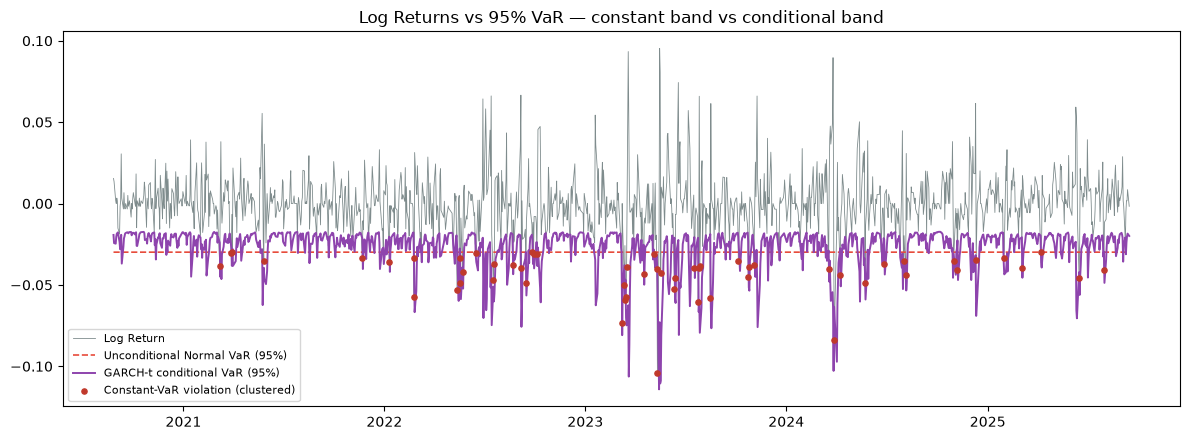

In [7]:
dates = safcom["Date"].iloc[-len(r):]
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(dates, r.values, color="#7f8c8d", lw=0.6, label="Log Return")
ax.plot(dates, -var_uncond.values, color="#e74c3c", lw=1.2, ls="--", label="Unconditional Normal VaR (95%)")
ax.plot(dates, -var_garch.values, color="#8e44ad", lw=1.4, label="GARCH-t conditional VaR (95%)")

# highlight where the CONSTANT VaR is breached — note how they bunch together
breach_u = r < -var_uncond
ax.scatter(dates[breach_u.values], r.values[breach_u.values], s=14, color="#c0392b",
           zorder=5, label="Constant-VaR violation (clustered)")
ax.set_title("Log Returns vs 95% VaR — constant band vs conditional band")
ax.legend(loc="lower left", fontsize=8); plt.tight_layout(); plt.show()

## Summary — what changed and where

| Fix | Original | Change | Effect |
|-----|----------|--------|--------|
| 1 | cells 10–11 | none — verified the data is already a clean NSE trading calendar | filter removes 0 rows; redundant, and civil ≠ exchange calendar |
| 2 | cells 59–60 | `period=21` → `period=252` | STL now matches the report's annual decomposition |
| 3 | cell 42 + md | fix skew wording (right-skew, not left) | risk attention on the correct tail |
| 4 | additive | adopt GMM **k=4** via BIC elbow + labels | one canonical regime taxonomy for the dashboard |
| 5 | additive | Kupiec **and** Christoffersen backtest | both pass Kupiec, but only conditional VaR passes independence |

**Original `Jeff_modeling.ipynb` is unchanged.** Apply by copying each **After** block over the
matching cell, or inserting the new cells for fixes 4–5.
